## 6-month PhD Research Proposal

Interbasin exchanges in stratified lakes

In [2]:
# imports
import ewgreaders as ewg
import xarray as xr
import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from tqdm.notebook import tqdm

### Aim 1: Controlling processes and spatiotemporal variability

#### WP 1.1: Physical forcing mechanisms

Physical processes:
- Riverine input
- Differential cooling
- Differential deepening
- Internal seiche pumping

#### WP 1.2: Temporal variability

N-S velocity at the constriction as a function of depth for each day in the first two weeks of January.

In [2]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

In [3]:
location = 'LZC'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
mxsc, mysc =  mreader.get_swiss_coords()
bathy = xr.open_dataset(mreader.BATHY_PATH.format(lake=lake))
deploy, retrieve = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
t_end = retrieve
adcps = mreader.get_adcps()

# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [4]:
all_adcp = []
for adcp in adcps:
    areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
    fpath = areader.locate_data_file('L0')
    ds = areader.load_from_L0()
    ds = ds.expand_dims(serial_id=[ds.attrs['serialnum']])
    areader.depth = depth_table.loc[depth_table['serial_id'] == adcp['serial_id'], 'depth'].iloc[0]
    ds = areader.range_to_depth(ds)
    ds['range'] = ds['range'].round(0)
    ds = areader.run_qa(ds)
    ds = ds.sel(time=slice(t_start, t_end))
    all_adcp.append(ds)

# shared time axis as mean of each instruments times
time_shared = (np.mean([ds.time.values.astype('int64') for ds in all_adcp], axis=0).astype('datetime64[ns]'))
all_adcp_aligned = [ds.assign_coords(time=time_shared) for ds in all_adcp]

# concatenate datasets and average common range bins
ds_combined = xr.concat(all_adcp_aligned, dim='range')
ds_combined = ds_combined.sortby('range')
ds_combined = ds_combined.groupby('range').mean()

# don't interplate over gap from opposite looking ADCPs in double frame
gap = np.arange(69, 73)
full_range = np.sort(np.concatenate([ds_combined.range.values, gap]))
ds_full = ds_combined.reindex(range=full_range)

# drop range bins with dubious data
bad_ranges = [68, 128, 129, 130]
ds_full = ds_full.drop_sel(range=bad_ranges)


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


C:\Users\herremha\AppData\Local\Temp\ipykernel_16692\2245932842.py:19: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'serial_id' ('serial_id',) The recommendation is to set join explicitly for this case.
  ds_combined = xr.concat(all_adcp_aligned, dim='range')


In [5]:
v = ds_full.vel.sel(dir='N').mean(dim='serial_id')
v = ewg.signal.valid_depths(v, 0.95)
v_df = v.to_dataframe().reset_index().drop(columns='dir')
v_df['date'] = v_df['time'].dt.date
v_df['month'] = v_df['time'].dt.month
v_df['day'] = v_df['time'].dt.day

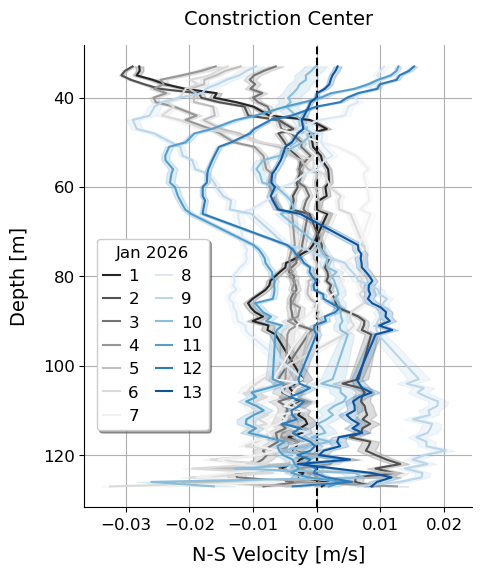

In [179]:
fig, ax = plt.subplots(figsize=(5, 6))

ax.axvline(0, color='black', linestyle='--')

sns.lineplot(v_df.query("month == 1 and day <= 7"), x='vel', y='range', orient='y', hue='date', palette='Grays_r', 
             errorbar=('se', 1), ax=ax, legend=True)
sns.lineplot(v_df.query("month == 1 and day > 7"), x='vel', y='range', orient='y', hue='date', palette='Blues', 
             errorbar=('se', 1), ax=ax, legend=True)

ax.set_xlabel('N-S Velocity [m/s]', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_title('Constriction Center', fontsize=14, pad=15)
ax.tick_params(axis='both', labelsize=12)

handles, labels = ax.get_legend_handles_labels()
labels = [int(x.split('-')[-1]) for x in labels]
#ax.legend(handles, labels, title='Jan 2026', fontsize=12, title_fontsize=12, fancybox=True, shadow=True, loc='upper right', bbox_to_anchor=(1.16, 1))
ax.legend(handles, labels, title='Jan 2026', ncols=2, fontsize=12, title_fontsize=12, fancybox=True, shadow=True, loc='upper left', bbox_to_anchor=(0.01, 0.6),
          handlelength=1.0, handletextpad=0.5, columnspacing=1)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.savefig('../gallery/surf/2026_03_16/temporal.svg', bbox_inches='tight')
plt.show()

#### WP 1.3: Spatial variability

Use `t_start` and `t_end` from LZN (Or first week of December).  Depth range 116.5 (88% valid LZN) to 127 m (deepest valid from LZC).

In [7]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

d_min = 116
d_max = 127

In [8]:
location = 'LZE'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
deploy, _ = mreader.get_deploy_retrieve_dates()
t_start = deploy + pd.Timedelta(days=1)
adcp = mreader.get_adcps()[0]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
t_end = ds.time.values.max() + pd.Timedelta(minutes=5)       # add 5 minutes to get equal samples
ds = ds.sel(time=slice(t_start, t_end))
ds_e = ds.sel(range=slice(d_max, d_min))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZE/L0\3U16576.000 ...


In [9]:
location = 'LZC'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
adcp = mreader.get_adcps()[-1]
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(time=slice(t_start, t_end))
ds_c = ds.sel(range=slice(d_max, d_min))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [10]:
# shared time axis as mean of each instruments times
time_shared = np.mean([ds_e.time.values.astype('int64'), ds_c.time.values.astype('int64')], axis=0).astype('datetime64[ns]')
ds_c = ds_c.assign_coords(time=time_shared)
ds_e = ds_e.assign_coords(time=time_shared)

In [11]:
uc = ds_c.vel.sel(dir='E')
vc = ds_c.vel.sel(dir='N')
speed_c = np.sqrt(uc**2 + vc**2)

ue = ds_e.vel.sel(dir='E')
ve = ds_e.vel.sel(dir='N')
speed_e = np.sqrt(ue**2 + ve**2)

# difference in flow magnitude
ds_speed = (speed_c.mean(dim='range') - speed_e.mean(dim='range')).sel(time=slice('2025-12-01', '2025-12-07'))

# 1-hour rolling average
ds_speed_ra = ds_speed.rolling(time=6, center=True).mean()

In [12]:
ds_anglec = ewg.lakes.flow_angle(ds_c)
ds_anglee = ewg.lakes.flow_angle(ds_e)

# difference in flow angle
ds_angle = (ds_anglec.mean(dim='range') - ds_anglee.mean(dim='range')).sel(time=slice('2025-12-01', '2025-12-07'))

# 1 hour rolling average
ds_angle_ra = ds_angle.rolling(time=6, center=True).mean()

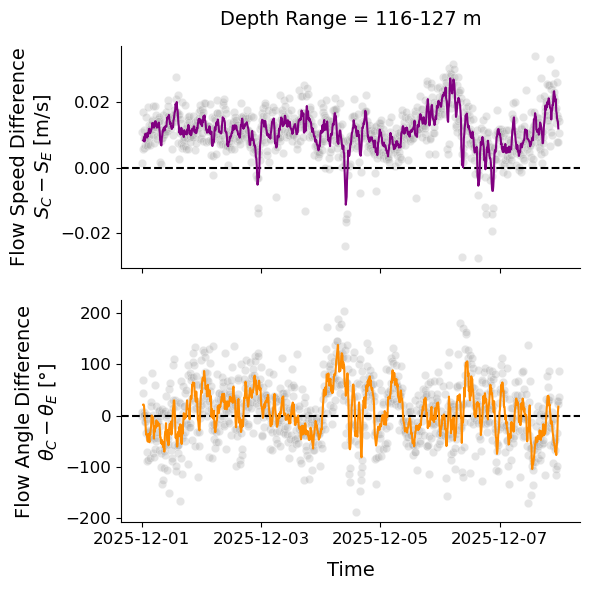

In [15]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(6, 6), sharex=True)

# flow speed
ax[0].axhline(0, color='black', linestyle='--')
sns.scatterplot(x=ds_speed.time, y=ds_speed, alpha=0.3, color='darkgray', ax=ax[0])
sns.lineplot(x=ds_speed_ra.time, y=ds_speed_ra, color='purple', ax=ax[0])

# flow angle
ax[1].axhline(0, color='black', linestyle='--')
sns.scatterplot(x=ds_angle.time, y=ds_angle, alpha=0.3, color='darkgray', ax=ax[1])
sns.lineplot(x=ds_angle_ra.time, y=ds_angle_ra, color='darkorange', ax=ax[1])

ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Flow Speed Difference\n' + r'$S_{C} - S_{E}$ [m/s]', fontsize=14)
ax[1].set_ylabel('Flow Angle Difference\n' + r'$\theta_{C} - \theta_{E}$ [°]', fontsize=14)
ax[0].set_title(f'Depth Range = {d_min}-{d_max} m', fontsize=14, pad=15)
ax[1].set_xticks(ax[1].get_xticks()[::2])

for i in range(len(ax)):
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)

plt.tight_layout(h_pad=2)
plt.savefig('../gallery/surf/2026_03_16/spatial.svg', bbox_inches='tight')
plt.show()

### Aim 2: Turbulent mixing and flow-boundary interactions

#### WP 2.1: Bathymetric and topographic enhancement of turbulence

Average between FP07 sensors for each profile, then average profiles at each location.

In [17]:
lake = 'Zugersee'
year = '2026'
date = '20260113'

dpath_L2 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/Microstructure/{date}/L2'
fpaths = glob(f'{dpath_L2}/*.nc')

In [18]:
eps_c, chi_c, K_c = [], [], []
eps_w, chi_w, K_w = [], [], []
eps_s, chi_s, K_s = [], [], []
for fpath in fpaths:
    ds = xr.open_dataset(fpath)
    mask = (ds['BINNED_flag_T1'] == 0) & (ds['BINNED_flag_T2'] == 0) & (ds['BINNED_depth'] > 5)

    eps = xr.concat([ds['BINNED_eps_T1'][mask], ds['BINNED_eps_T2'][mask]], dim='sensor').mean(dim='sensor')
    chi = xr.concat([ds['BINNED_Xi_T1'][mask], ds['BINNED_Xi_T2'][mask]], dim='sensor').mean(dim='sensor')
    K = xr.concat([ds['BINNED_KOsbornCox_T1'][mask], ds['BINNED_KOsbornCox_T2'][mask]], dim='sensor').mean(dim='sensor')

    # VMPS
    if 'DAT_053' in fpath:
        eps_s.append(eps)
        chi_s.append(chi)
        K_s.append(K)

    # VMPC
    elif 'DAT_055' in fpath or 'DAT_059' in fpath:
        eps_c.append(eps)
        chi_c.append(chi)
        K_c.append(K)

    # VMPW
    elif 'DAT_057' in fpath:
        eps_w.append(eps)
        chi_w.append(chi)
        K_w.append(K)

In [19]:
eps_s = xr.concat(eps_s, dim='BINNED_depth').sortby('BINNED_depth')
chi_s = xr.concat(chi_s, dim='BINNED_depth').sortby('BINNED_depth')
K_s = xr.concat(K_s, dim='BINNED_depth').sortby('BINNED_depth')

eps_c = xr.concat(eps_c, dim='BINNED_depth').sortby('BINNED_depth')
chi_c = xr.concat(chi_c, dim='BINNED_depth').sortby('BINNED_depth')
K_c = xr.concat(K_c, dim='BINNED_depth').sortby('BINNED_depth')

eps_w = xr.concat(eps_w, dim='BINNED_depth').sortby('BINNED_depth')
chi_w = xr.concat(chi_w, dim='BINNED_depth').sortby('BINNED_depth')
K_w = xr.concat(K_w, dim='BINNED_depth').sortby('BINNED_depth')

In [20]:
bins_s = np.arange(0, eps_s['BINNED_depth'].max() + 5, 5)
eps_s_avg = eps_s.groupby_bins("BINNED_depth", bins_s).median()
chi_s_avg = chi_s.groupby_bins("BINNED_depth", bins_s).median()
K_s_avg = K_s.groupby_bins("BINNED_depth", bins_s).median()
bc_s = np.array([b.mid for b in eps_s_avg['BINNED_depth_bins'].values])

bins_c = np.arange(0, eps_c['BINNED_depth'].max() + 5, 5)
eps_c_avg = eps_c.groupby_bins("BINNED_depth", bins_c).median()
chi_c_avg = chi_c.groupby_bins("BINNED_depth", bins_c).median()
K_c_avg = K_c.groupby_bins("BINNED_depth", bins_c).median()
bc_c = np.array([b.mid for b in eps_c_avg['BINNED_depth_bins'].values])

bins_w = np.arange(0, eps_w['BINNED_depth'].max() + 5, 5)
eps_w_avg = eps_w.groupby_bins("BINNED_depth", bins_w).median()
chi_w_avg = chi_w.groupby_bins("BINNED_depth", bins_w).median()
K_w_avg = K_w.groupby_bins("BINNED_depth", bins_w).median()
bc_w = np.array([b.mid for b in eps_w_avg['BINNED_depth_bins'].values])

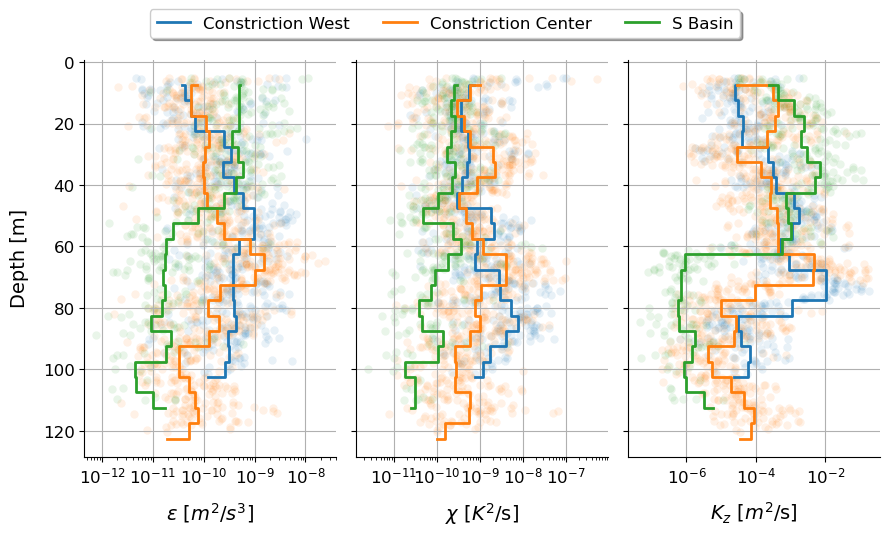

In [21]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(9, 5), sharey=True)
palette = sns.color_palette('tab10')

# epsilon
sns.scatterplot(x=eps_w, y=eps_w['BINNED_depth'], color=palette[0], alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_w_avg, y=bc_w, orient='y', color=palette[0], linewidth=2, drawstyle="steps-mid", ax=ax[0], label='Constriction West')

sns.scatterplot(x=eps_c, y=eps_c['BINNED_depth'], color=palette[1], alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_c_avg, y=bc_c, orient='y', color=palette[1], linewidth=2, drawstyle="steps-mid", ax=ax[0], label='Constriction Center')

sns.scatterplot(x=eps_s, y=eps_s['BINNED_depth'], color=palette[2], alpha=0.1, ax=ax[0])
sns.lineplot(x=eps_s_avg, y=bc_s, orient='y', color=palette[2], linewidth=2, drawstyle="steps-mid", ax=ax[0], label='S Basin')

# chi
sns.scatterplot(x=chi_w, y=chi_w['BINNED_depth'], color=palette[0], alpha=0.1, ax=ax[1])
sns.lineplot(x=chi_w_avg, y=bc_w, orient='y', color=palette[0], linewidth=2, drawstyle="steps-mid", ax=ax[1])

sns.scatterplot(x=chi_c, y=chi_c['BINNED_depth'], color=palette[1], alpha=0.1, ax=ax[1])
sns.lineplot(x=chi_c_avg, y=bc_c, orient='y', color=palette[1], linewidth=2, drawstyle="steps-mid", ax=ax[1])

sns.scatterplot(x=chi_s, y=chi_s['BINNED_depth'], color=palette[2], alpha=0.1, ax=ax[1])
sns.lineplot(x=chi_s_avg, y=bc_s, orient='y', color=palette[2], linewidth=2, drawstyle="steps-mid", ax=ax[1])

# K
sns.scatterplot(x=K_w, y=K_w['BINNED_depth'], color=palette[0], alpha=0.1, ax=ax[2])
sns.lineplot(x=K_w_avg, y=bc_w, orient='y', color=palette[0], linewidth=2, drawstyle="steps-mid", ax=ax[2])

sns.scatterplot(x=K_c, y=K_c['BINNED_depth'], color=palette[1], alpha=0.1, ax=ax[2])
sns.lineplot(x=K_c_avg, y=bc_c, orient='y', color=palette[1], linewidth=2, drawstyle="steps-mid", ax=ax[2])

sns.scatterplot(x=K_s, y=K_s['BINNED_depth'], color=palette[2], alpha=0.1, ax=ax[2])
sns.lineplot(x=K_s_avg, y=bc_s, orient='y', color=palette[2], linewidth=2, drawstyle="steps-mid", ax=ax[2])

ax[0].set_xlabel(r'$\epsilon$ [$m^{2}$/$s^{3}$]', fontsize=14, labelpad=10)
ax[1].set_xlabel(r'$\chi$ [$K^{2}$/s]', fontsize=14, labelpad=10)
ax[2].set_xlabel(r'$K_{z}$ [$m^{2}$/s]', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

handles, labels = ax[0].get_legend_handles_labels()
ax[0].get_legend().remove()
fig.legend(handles, labels, fontsize=12, ncols=3, shadow=True, loc='upper center', bbox_to_anchor=(0.5, 1.08))

ax[0].invert_yaxis()
for i in range(len(ax)):
    ax[i].set_xscale('log')
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

plt.tight_layout()
plt.savefig('../gallery/surf/2026_03_16/turbulence.svg', bbox_inches='tight')
plt.show()

#### WP: 2.2: Flow generation of turbulent mixing

#### WP 2.3: Flow advection of dissipated energy and instabilities

In [180]:
lake = 'Zugersee'
year = '2026'
date = '20260213'

dpath_L1 = f'Q:Messdaten/Aphys_Hypothesis_data/{lake}/{year}/CTD/{date}/L1'

In [181]:
for p in os.listdir(dpath_L1):
    fpath = os.path.join(dpath_L1, p)
    ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
    ds = ctdreader.load_from_L1()

    if ds.attrs['Profile name'] == 'VMPS':
        # data quality
        mask = (ds['depth'].notnull()) & (ds['Temp_qual'] == 0) & (ds['Cond_qual'] == 0) & (ds[f'DO_mg_qual'] == 0)
        mask = mask & (ds['depth'] > 5)
        depth = ds['depth'][mask]
        temp = ds['Temp'][mask]
        cond = ds['Cond'][mask]
        rho = ds['rho'][mask]
        do = ds['DO_mg'][mask]

        # smoth density and salinity profile
        rho = xr.DataArray(ewg.signal.rolling_average(rho, depth, 1), dims='time', coords={'time': rho['time'].values}, name='rho')
        cond = xr.DataArray(ewg.signal.rolling_average(cond, depth, 1), dims='time', coords={'time': cond['time'].values}, name='cond')

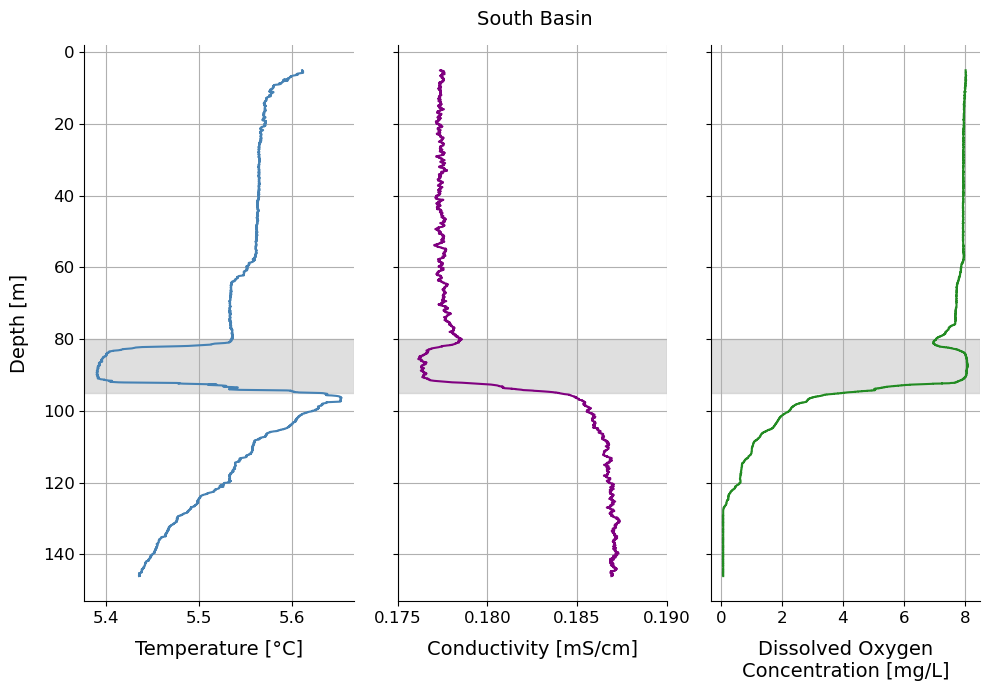

In [220]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(10, 7), sharey=True)

ax[0].plot(temp, depth, color='steelblue')
ax[1].plot(cond, depth, color='purple')
ax[2].plot(do, depth, color='forestgreen')

ax[0].set_xlabel('Temperature [°C]', fontsize=14, labelpad=10)
ax[1].set_xlabel('Conductivity [mS/cm]', fontsize=14, labelpad=10)
ax[2].set_xlabel('Dissolved Oxygen\nConcentration [mg/L]', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[1].set_xticks(ax[1].get_xticks()[::2])

for i in range(len(ax)):
    ax[i].axhspan(80, 95, color='silver', alpha=0.5)
    ax[i].tick_params(axis='both', labelsize=12)
    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

fig.suptitle('South Basin', fontsize=14, x=0.54)
ax[0].invert_yaxis()
plt.tight_layout()
plt.savefig('../gallery/surf/2026_03_16/intrusion.svg', bbox_inches='tight')
plt.show()

### Aim 3: Horizontal pathway for deep water renewal

#### WP 3.1: Identification of renewal events

How often does deep water renewal occur?

In [41]:
def calculate_transect_min_do(dpath_L1):
    # transect minimum
    min_do = []
    for p in os.listdir(dpath_L1):
        fpath = os.path.join(dpath_L1, p)
        
        ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
        ds = ctdreader.load_from_L1()

        # data quality
        mask = (ds['depth'].notnull()) & (ds[f'DO_mg_qual'] == 0)
        do = ds['DO_mg'][mask]
        min_do.append(do.min().item())

    return min(min_do)

In [42]:
years = ['2025', '2026']
anoxia_data = []
for year in years:
    ctd_root = f'Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/{year}/CTD'

    for date in tqdm(os.listdir(ctd_root)):
        if date > '20251029' and date < '20260309':
            dpath_L1 = os.path.join(ctd_root, date, 'L1')
            for p in os.listdir(dpath_L1):
                fpath = os.path.join(dpath_L1, p)
                ctdreader = ewg.ctd_reader.CTDReader(lake, year, date, fpath)
                ds = ctdreader.load_from_L1()

                ysc = int(ds.attrs['Y Coordinate (CH1903)']) + int(1e6)
                if ysc < 1217437:
                    min_do = calculate_transect_min_do(dpath_L1)
                    
                    # data quality
                    mask = (ds['depth'].notnull()) & (ds[f'DO_mg_qual'] == 0)
                    depth = ds['depth'][mask]
                    do = ds['DO_mg'][mask]

                    try:
                        idx = np.where(do <= min_do + 0.2)[0][0]
                        z = depth[idx].item()
                    except IndexError:
                        z = np.nan

                    anoxia_data.append({
                        'date': pd.to_datetime(date, format='%Y%m%d'),
                        'anoxic_depth': z
                    })

anoxia_data = pd.DataFrame(anoxia_data)

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/11 [00:00<?, ?it/s]

C:\Users\herremha\AppData\Local\Temp\ipykernel_16692\992285581.py:5: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  sns.scatterplot(anoxia_data.query("date == '2026-02-13'"), x='date', y='anoxic_depth', marker='X', s=100, color='limegreen', zorder=2, ax=ax)


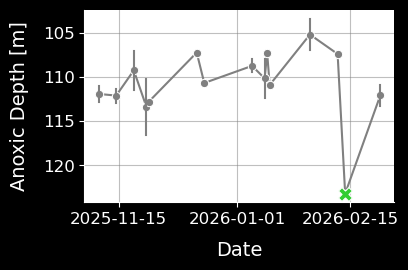

In [219]:
fig, ax = plt.subplots(figsize=(4, 2.5))

sns.lineplot(anoxia_data, x='date', y='anoxic_depth', marker='o', errorbar=('se', 1), err_style='bars', color='gray', ax=ax)

sns.scatterplot(anoxia_data.query("date == '2026-02-13'"), x='date', y='anoxic_depth', marker='X', s=100, color='limegreen', zorder=2, ax=ax)


ax.set_xlabel('Date', fontsize=14, labelpad=10, color='white')
ax.set_ylabel('Anoxic Depth [m]', fontsize=14, labelpad=10, color='white')
#ax.set_title('South Basin', fontsize=14, color='white')
ax.tick_params(axis='both', labelsize=12, colors='white')
ax.set_xticks(ax.get_xticks()[::3])

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
#ax.grid(True)
ax.grid(True, color='gray', linestyle='-', alpha=0.5)

fig.patch.set_facecolor('black')
#ax.set_facecolor('black')

plt.savefig('../gallery/surf/2026_03_16/anoxia.svg', bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()

#### WP 3.2: Calculation of horizontal contribution

Deep water renewal from vertical convective circulation, horizontal interbasin exchanges, and horizontal littoral-pelagic exchanges

In [123]:
lake = 'Zugersee'
year = '2026'
date = '20260114'

t_start = '2026-01-10'
t_end = '2026-01-12'

In [124]:
location = 'LZC'

mreader = ewg.mooring_reader.MooringReader(lake, location, year, date)
adcp = mreader.get_adcps()[-1]
oxygen_loggers = mreader.get_oxygen_loggers()
thermistors = mreader.get_thermistors()

# linear regression from known depths
sensor_depths = mreader.extract_sensor_depths()
m, b, _, _, _ = scipy.stats.linregress(sensor_depths.depth_md, sensor_depths.depth_sensor)
instruments = mreader.get_instruments(pandas=True)
instruments['depth_md'] = mreader.total_depth - instruments['mab']
instruments['depth_lr'] = m * instruments['depth_md'] + b

# use known depths where available
depth_table = pd.merge(instruments, sensor_depths, how='outer')
depth_table['depth'] = depth_table['depth_sensor'].fillna(depth_table['depth_lr']).round(1)
depth_table = depth_table.sort_values('depth')


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\12U8315.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U672.000 ...

Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\6D1728.000 ...


C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\adcp_reader.py:81: UserWarning: No pressure measurements on ADCP, calculating depth from metadata.
  warnings.warn('No pressure measurements on ADCP, calculating depth from metadata.')



Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [125]:
ds_chain = []
for ol in oxygen_loggers:

    oreader = ewg.o2_reader.O2Reader(ol['serial_id'], lake, location, year, date)
    fpath = os.path.join(mreader.dpath_L0, f"7450-{ol['serial_id']}/Cat.txt")
    oreader.depth = depth_table.loc[depth_table['serial_id'] == ol['serial_id'], 'depth'].iloc[0]
    ds = oreader.load_from_L0()
    ds = ds.sel(time=slice(t_start, t_end))
    #ds['d_oxygen_conc'] *= (1000/32)    # conver to umol/L
    ds_chain.append(ds)

ds_do = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


In [126]:
# time of maximum oxygen at depth
ds_do_sel = ds_do.sel(depth=ds_do.depth.min().item())
idx = ds_do_sel.d_oxygen_conc.argmax()
t0 = ds_do_sel.d_oxygen_conc[idx].time.values

In [127]:
ds_chain = []
for t in thermistors:

    treader = ewg.thermistor_reader.ThermistorReader(t['serial_id'], lake, location, year, date)
    treader.depth = depth_table.loc[depth_table['serial_id'] == t['serial_id'], 'depth'].iloc[0]
    if treader.depth >= ds_do.depth.min().item() and treader.depth <= ds_do.depth.max().item():
        ds = treader.load_from_L0()
        ds = ds.sel(time=slice(t_start, t_end))
        ds_chain.append(ds)

ds_temp = mreader.create_instrument_chain(ds_chain)

C:\Users\herremha\elcres\ewgreaders\ewgreaders\readers\mooring_reader.py:314: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  return xr.concat(ds_aligned, dim='depth')


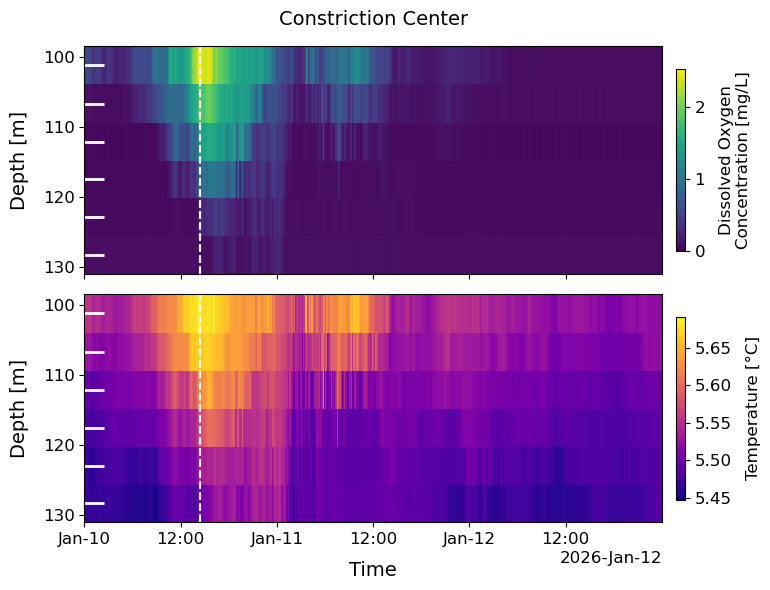

In [128]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(8, 6), sharex=True, sharey=True)

ax[0].axvline(t0, color='white', linestyle='--')
# oxygen and oxygen logger depths
im = ds_do.d_oxygen_conc.plot(cmap='viridis', vmin=0, cbar_kwargs={'shrink': 0.8, 'pad':0.02}, rasterized=True, ax=ax[0])
im.colorbar.ax.tick_params(labelsize=12)
im.colorbar.ax.set_ylabel('Dissolved Oxygen\nConcentration [mg/L]', fontsize=12, labelpad=10)
for d in ds_do.depth:
    ax[0].plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax[0].get_yaxis_transform(), clip_on=False)

ax[1].axvline(t0, color='white', linestyle='--')
# temperature and thermistor depths
im = ds_temp.temp.plot(cmap='plasma', cbar_kwargs={'shrink': 0.8, 'pad':0.02}, rasterized=True, ax=ax[1])
im.colorbar.ax.tick_params(labelsize=12)
im.colorbar.ax.set_ylabel('Temperature [°C]', fontsize=12, labelpad=10)
ax[1].xaxis.get_offset_text().set_fontsize(12)
for d in ds_temp.depth:
    ax[1].plot(0.01, d.item(), marker='_', markersize=20, markeredgewidth=2, color='white', transform=ax[1].get_yaxis_transform(), clip_on=False)

ax[0].set_xlabel('')
ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax[0].set_title('Constriction Center', fontsize=14, pad=15)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='both', labelsize=12)
ax[0].invert_yaxis()

plt.tight_layout()
plt.savefig('../gallery/surf/2026_03_16/do_temp.svg', bbox_inches='tight')
plt.show()

In [129]:
areader = ewg.adcp_reader.ADCPReader(adcp['serial_id'], lake, location, year, date)
ds = areader.load_from_L0()
ds = areader.range_to_depth(ds)
ds = areader.run_qa(ds)
ds = ds.sel(range=slice(ds_do.depth.max().item(), ds_do.depth.min().item()))
ds_adcp = ds.sel(time=slice(t0, t_end))


Reading file Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/2026/Mooring/20260114/LZC/L0\3U16549.000 ...


In [130]:
v_avg = ds_adcp.vel.sel(dir='N').mean(dim='range')
v_ra = v_avg.rolling(time=6, center=True).mean()    # 1-hour rolling average
dt = ds_adcp.time.diff('time').astype('timedelta64[s]').astype(float)
dt = dt.reindex(time=ds.time, method='pad')
r = (v_avg * dt).cumsum('time')

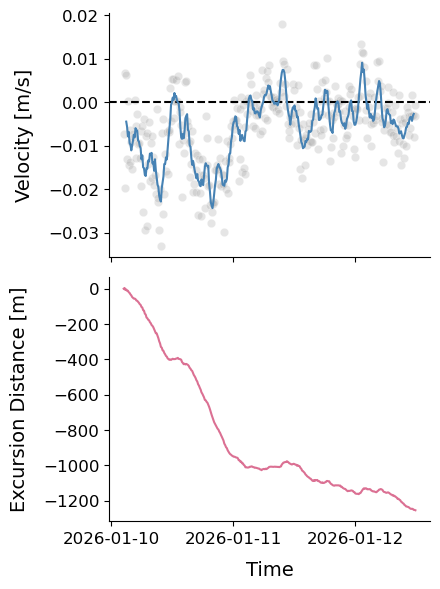

In [131]:
fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(4.5, 6), sharex=True)

ax[0].axhline(0, color='black', linestyle='--')
sns.scatterplot(x=v_avg.time, y=v_avg, alpha=0.3, color='darkgray', ax=ax[0])
sns.lineplot(x=v_ra.time, y=v_ra, color='steelblue', ax=ax[0])

sns.lineplot(x=r.time, y=r, color='palevioletred', ax=ax[1])

ax[1].set_xlabel('Time', fontsize=14, labelpad=10)
ax[1].set_xticks(ax[1].get_xticks()[::4])
ax[0].set_ylabel('Velocity [m/s]', fontsize=14, labelpad=10)
ax[1].set_ylabel('Excursion Distance [m]', fontsize=14, labelpad=10)
ax[0].tick_params(axis='y', labelsize=12)
ax[1].tick_params(axis='both', labelsize=12)

ax[0].spines[['right', 'top']].set_visible(False)
ax[1].spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.savefig('../gallery/surf/2026_03_16/excursion.svg', bbox_inches='tight')
plt.show()

### Methodology

In [3]:
bathy_zug = xr.open_dataset('Q:/Messdaten/Aphys_Hypothesis_data/Zugersee/bathymetry.nc')

# planned locations
locs_zug = pd.DataFrame({
    'name': ["P1", "P2", "P3", "VMPN", "P05'", "P05''", "LZC", "LZW", "LZE", "P7", "P8", "P9", "VMPS", "P10", "P11", "P12", "L1", "L2", "L3"],
    'xsc': [679803, 679803, 679663, 679250, 679322, 679711, 680090, 679884, 680328, 680150, 680223, 680409, 680600, 680814, 681350, 681909, 679322, 679322, 681510],
    'ysc': [224100, 222690, 221650, 220433, 219531, 219097, 218816, 218764, 218866, 218462, 218126, 217437, 216834, 216239, 214957, 213760, 217600, 215450, 216934],
    'mooring': [False, False, False, False, True, False, True, True, True, False, False, True, False, False, False, False, False, False, False],
    'microstructure': [False, False, False, True, False, False, True, True, True, False, False, False, True, False, False, False, False, False, False],
    'water_sample': [False, False, False, True, False, False, True, False, False, False, False, False, True, False, False, False, True, True, True]
})
# VMPS xsc = 680442
locs_zug['xsc'] += int(2e6)
locs_zug['ysc'] += int(1e6)
locs_zug['total_depth'] = [bathy_zug.sel(xsc=row.xsc, ysc=row.ysc).depth.item() for _, row in locs_zug.iterrows()]

# transect for bathymetry
locs_zug_transect = locs_zug[~locs_zug['name'].isin(['LZW', 'LZE', 'L1', 'L2', 'L3'])]

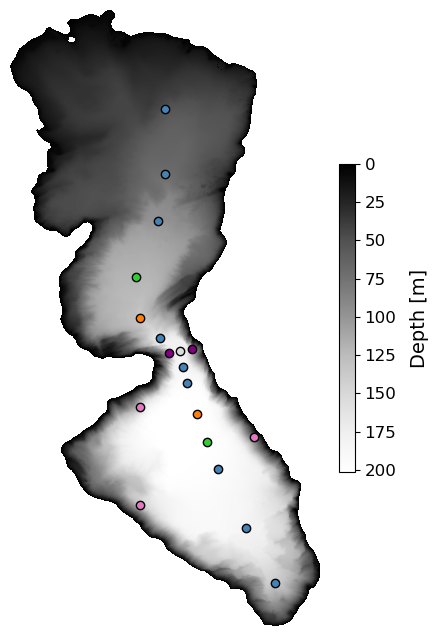

In [10]:
fig, ax = plt.subplots(figsize=(5, 8))

im = ax.pcolormesh(bathy_zug['xsc'], bathy_zug['ysc'], bathy_zug['depth'], cmap='Greys_r', vmin=0, rasterized=True)
cbar = fig.colorbar(im, shrink=0.5, ax=ax)
cbar.set_label('Depth [m]', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()

# fieldwork locations
for _, row in locs_zug.iterrows():
    if row['mooring'] and row['microstructure'] and row['water_sample']:
        color = 'gainsboro'
    elif row['mooring'] and row['microstructure']:
        color = 'purple'
    elif row['mooring']:
        color = 'tab:orange'
    elif row['microstructure'] and row['water_sample']:
        color = 'limegreen'
    elif row['water_sample']:
        color = 'tab:pink'
    else:
        color = 'steelblue'

    ax.scatter(row.xsc, row.ysc, c=color, edgecolor='black')
    #ax.annotate(row['name'], (row.xsc, row.ysc), color='red', xytext=(3, 0), textcoords='offset points')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/zug_map.svg', bbox_inches='tight')
plt.show()

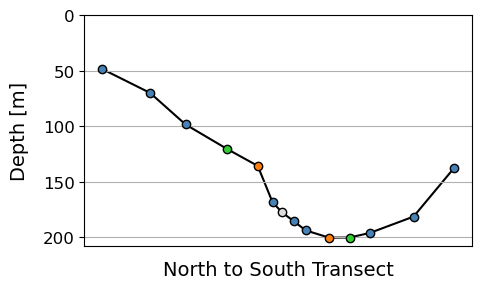

In [6]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.lineplot(locs_zug_transect, x='ysc', y='total_depth', color='black', marker=None, zorder=1, ax=ax)

# fieldwork locations
for _, row in locs_zug_transect.iterrows():
    if row['mooring'] and row['microstructure'] and row['water_sample']:
        color = 'gainsboro'
    elif row['mooring'] and row['microstructure']:
        color = 'purple'
    elif row['mooring']:
        color = 'tab:orange'
    elif row['microstructure'] and row['water_sample']:
        color = 'limegreen'
    elif row['water_sample']:
        color = 'tab:pink'
    else:
        color = 'steelblue'

    ax.scatter(row.ysc, row.total_depth, c=color, edgecolor='black', zorder=2)

ax.set_xlabel('North to South Transect', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_xticks([])
ax.tick_params(axis='both', labelsize=12)

ax.set_ylim(0, None)
ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(True, zorder=0)
plt.savefig('../gallery/surf/2026_03_16/zug_transect.svg', bbox_inches='tight')
plt.show()

In [7]:
bathy_lucerne = xr.open_dataset('Q:/Messdaten/Aphys_Hypothesis_data/Lucerne/bathymetry.nc')
bathy_lucerne_sel = bathy_lucerne.sel(xsc=slice(2674000, None), ysc=slice(None, 1206500))

# planned locations
locs_lucerne = pd.DataFrame({
    'name': ["P1", "P2", "P3", "P4", "P5", "P6", "P7", "P7S", "P7N", "P8", "P9", "P10", "P11", "P12", "P13", "P14", "L1", "L2"],
    'xsc': [689164, 688831, 688597, 688597, 688620, 688460, 687945, 687870, 688020, 687442, 686760, 685900, 684542, 683150, 681157, 678966, 687450, 689700],
    'ysc': [195729, 197528, 200315, 202685, 204100, 204750, 205025, 204800, 205250, 205150, 205150, 204700, 204000, 203740, 203590, 203863, 200315, 200315],
    'mooring': [False, False, False, True, False, False, True, True, True, False, False, True, True, False, False, False, False, False],
    'microstructure': [False, False, True, False, False, False, True, True, True, False, False, True, True, False, True, False, False, False],
    'water_sample': [False, False, True, False, False, False, True, False, False, False, False, True, False, False, True, False, True, True]
})

locs_lucerne['xsc'] += int(2e6)
locs_lucerne['ysc'] += int(1e6)
locs_lucerne['total_depth'] = [bathy_lucerne.sel(xsc=row.xsc, ysc=row.ysc).depth.item() for _, row in locs_lucerne.iterrows()]

# distance along transect from Gersaursee to Urnersee
locs_lucerne_transect = locs_lucerne[~locs_lucerne['name'].isin(['P7S', 'P7N', 'L1', 'L2'])]
x = np.diff(locs_lucerne_transect.xsc[::-1])    # reverse order
y = np.diff(locs_lucerne_transect.ysc[::-1])
dist = np.sqrt(x**2 + y**2)
dist_transect = np.concatenate([np.array([0]), np.cumsum(dist)])
locs_lucerne_transect['dist_transect'] = dist_transect[::-1]    # reverse order back

C:\Users\herremha\AppData\Local\Temp\ipykernel_34360\493447813.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  locs_lucerne_transect['dist_transect'] = dist_transect[::-1]    # reverse order back


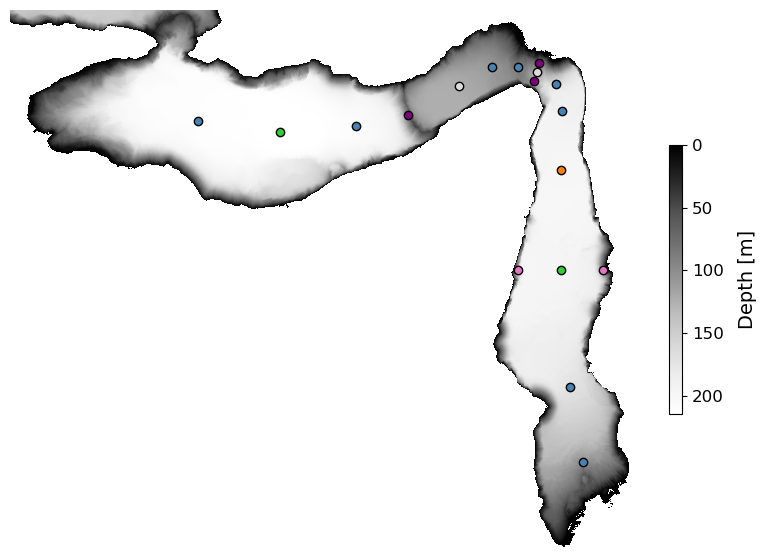

In [3]:
fig, ax = plt.subplots(figsize=(10, 7))

im = ax.pcolormesh(bathy_lucerne_sel['xsc'], bathy_lucerne_sel['ysc'], bathy_lucerne_sel['depth'], cmap='Greys_r', vmin=0, rasterized=True)
cbar = fig.colorbar(im, shrink=0.5, ax=ax)
cbar.set_label('Depth [m]', fontsize=14, labelpad=10)
cbar.ax.tick_params(labelsize=12)
cbar.ax.invert_yaxis()

# fieldwork locations
for _, row in locs_lucerne.iterrows():
    if row['mooring'] and row['microstructure'] and row['water_sample']:
        color = 'gainsboro'
    elif row['mooring'] and row['microstructure']:
        color = 'purple'
    elif row['mooring']:
        color = 'tab:orange'
    elif row['microstructure'] and row['water_sample']:
        color = 'limegreen'
    elif row['water_sample']:
        color = 'tab:pink'
    else:
        color = 'steelblue'

    ax.scatter(row.xsc, row.ysc, c=color, edgecolor='black')

ax.set_xticks([])
ax.set_yticks([])
ax.spines[['right', 'top', 'left', 'bottom']].set_visible(False)

plt.savefig('../gallery/surf/2026_03_16/lucerne_map.svg', bbox_inches='tight')
plt.show()

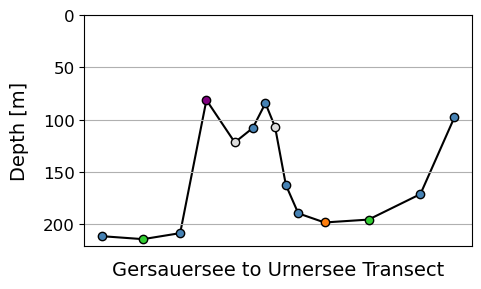

In [8]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.lineplot(locs_lucerne_transect, x='dist_transect', y='total_depth', color='black', marker=None, zorder=1, ax=ax)

# fieldwork locations
for _, row in locs_lucerne_transect.iterrows():
    if row['mooring'] and row['microstructure'] and row['water_sample']:
        color = 'gainsboro'
    elif row['mooring'] and row['microstructure']:
        color = 'purple'
    elif row['mooring']:
        color = 'tab:orange'
    elif row['microstructure'] and row['water_sample']:
        color = 'limegreen'
    elif row['water_sample']:
        color = 'tab:pink'
    else:
        color = 'steelblue'

    ax.scatter(row.dist_transect, row.total_depth, c=color, edgecolor='black', zorder=2)

ax.set_xlabel('Gersauersee to Urnersee Transect', fontsize=14, labelpad=10)
ax.set_ylabel('Depth [m]', fontsize=14, labelpad=10)
ax.set_xticks([])
ax.tick_params(axis='both', labelsize=12)

ax.set_ylim(0, None)
ax.invert_yaxis()
ax.grid(True, zorder=0)

plt.savefig('../gallery/surf/2026_03_16/lucerne_transect.svg', bbox_inches='tight')
plt.show()

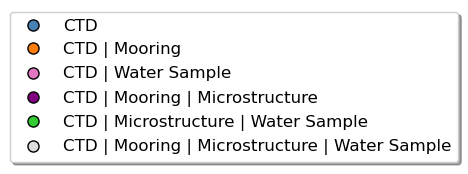

In [6]:
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(5, 2))

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='CTD', markerfacecolor='steelblue', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='CTD | Mooring', markerfacecolor='tab:orange', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='CTD | Water Sample', markerfacecolor='tab:pink', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='CTD | Mooring | Microstructure', markerfacecolor='purple', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='CTD | Microstructure | Water Sample', markerfacecolor='limegreen', markeredgecolor='black', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='CTD | Mooring | Microstructure | Water Sample', markerfacecolor='gainsboro', markeredgecolor='black', markersize=8)
]

ax.legend(handles=legend_elements, loc='center', frameon=True, fancybox=True, shadow=True, fontsize=12)
ax.axis('off')

plt.savefig('../gallery/surf/2026_03_16/field_legend.svg', bbox_inches='tight')
plt.show()